In [1]:
#Implementing all the libraries and Bringing of the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

csv_file_path = r"D:\data.csv"
data = pd.read_csv(csv_file_path)
print(data.head())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [2]:
print(data.describe())

              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   862.168977   
min       

In [3]:
#Step 1: Preprocessing the Dataset
#1 Removing the unnecessary columns 
data = data.drop(['date', 'street', 'country'], axis=1, errors='ignore')  #Optional Safe Drop
#2 Handling the Missing Values
data.isnull().sum() #This will tell that does any of our columns have a misssing value if yes than we will fill numerical columns with median and categorical columns with  mode 
#3 Feature Engineering (Converting raw data to smarter data for boosting the accuracy)
data['house_age'] = 2025 - data['yr_built']
data = data.drop('yr_built', axis=1)
data['renovated'] = data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
data = data.drop('yr_renovated', axis=1)
data['has_basement'] = data['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)
data["area_per_bedroom"] = data["sqft_living"] / data["bedrooms"]
data["bathroom_to_bedroom_ratio"] = data["bathrooms"] / data["bedrooms"]


#4 Encoding  Categorical Features
data = pd.get_dummies(data, columns=['city', 'statezip'], drop_first=True) #One Hot Encoding is used 
#5 Handling the outliers (Using IQR for this)
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['price'] >= Q1 - 1.5*IQR) & (data['price'] <= Q3 + 1.5*IQR)]
#6 Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['sqft_living','sqft_lot','sqft_above','sqft_basement','bedrooms','bathrooms','floors']
data[num_cols] = scaler.fit_transform(data[num_cols])
#7 Convert all boolean columns to int (0/1)
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

#8 Splitting features and target
X = data.drop('price', axis=1)
y = data['price']
print (data.head())

      price  bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront  \
0  313000.0 -0.404730  -0.829364    -0.850818 -0.186052  0.008976           0   
2  342000.0 -0.404730  -0.139546    -0.132879 -0.074128 -0.922823           0   
3  420000.0 -0.404730   0.205363    -0.047700 -0.182779 -0.922823           0   
4  550000.0  0.723545   0.550272    -0.120710 -0.114265 -0.922823           0   
5  490000.0 -1.533005  -1.519181    -1.410566 -0.228546 -0.922823           0   

   view  condition  sqft_above  ...  statezip_WA 98155  statezip_WA 98166  \
0     0          3   -0.533700  ...                  0                  0   
2     0          4    0.228405  ...                  0                  0   
3     0          4   -0.972878  ...                  0                  0   
4     0          4   -0.792040  ...                  0                  0   
5     0          3   -1.127883  ...                  0                  0   

   statezip_WA 98168  statezip_WA 98177  statezip_

In [4]:
# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# Step 3 Base Model
xgb = XGBRegressor(random_state=42, n_jobs=-1)

In [6]:
# Step 4: Define parameter grid
param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [7]:
# Step 5: GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [200, 500, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [8]:
# Step 8: Evaluate Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("R2 Score on Test Data:", r2)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 800, 'subsample': 0.8}
R2 Score on Test Data: 0.7276004066607051


<Figure size 1200x800 with 0 Axes>

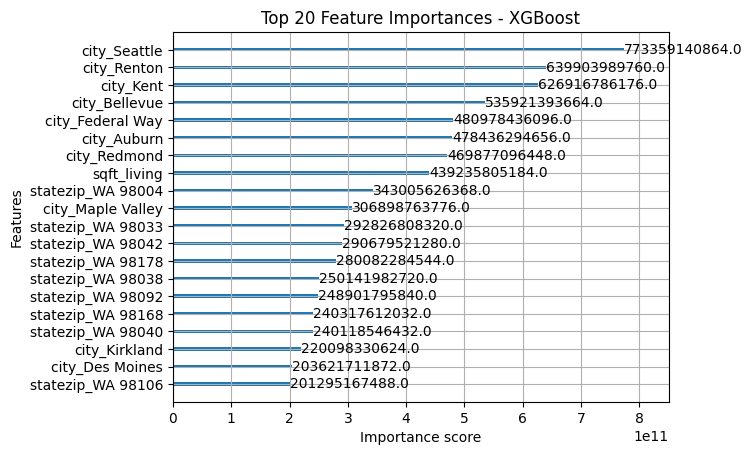

In [9]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot Feature Importance
plt.figure(figsize=(12, 8))
plot_importance(grid_search.best_estimator_, importance_type='gain', max_num_features=20)  
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()


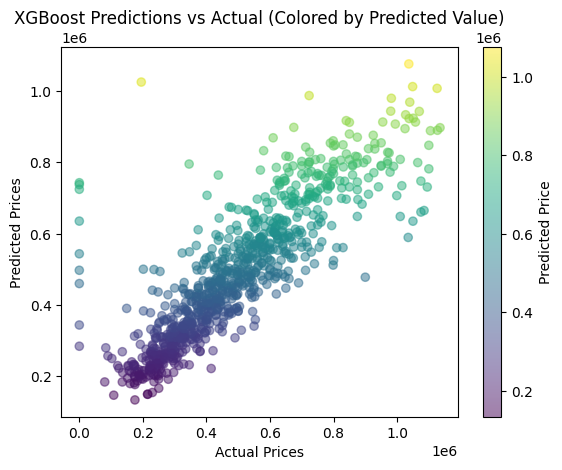

In [10]:
plt.scatter(y_test, y_pred, alpha=0.5, c=y_pred, cmap="viridis")
plt.colorbar(label="Predicted Price")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("XGBoost Predictions vs Actual (Colored by Predicted Value)")
plt.show()


In [11]:
import pickle
import joblib
import pandas as pd

# Folder path
folder_path = r"C:\Users\LENOVO\Desktop\HousePriceApp"

# Save trained XGBoost model
with open(f"{folder_path}/xgb_house_price_model.pkl", "wb") as f:
    pickle.dump(grid_search.best_estimator_, f)

# Save scaler
joblib.dump(scaler, f"{folder_path}/scaler.pkl")

# Save columns used in training (important for alignment)
columns = X.columns  # X is your training features
with open(f"{folder_path}/columns.pkl", "wb") as f:
    pickle.dump(columns, f)


In [12]:
import pickle
import joblib
import pandas as pd
import os

# Folder path
folder_path = r"C:\Users\LENOVO\Desktop\HousePriceApp"

# Load model, scaler, and columns
with open(os.path.join(folder_path, "xgb_house_price_model.pkl"), "rb") as f:
    model = pickle.load(f)

scaler = joblib.load(os.path.join(folder_path, "scaler.pkl"))

with open(os.path.join(folder_path, "columns.pkl"), "rb") as f:
    columns = pickle.load(f)

def predict_price(input_data):
    """
    input_data: dict with keys like bedrooms, bathrooms, sqft_living, city, statezip, etc.
    """
    df = pd.DataFrame([input_data])
    
    # Feature Engineering
    df['house_age'] = 2025 - df['yr_built']
    df['renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
    df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)
    df["area_per_bedroom"] = df["sqft_living"] / df["bedrooms"]
    df["bathroom_to_bedroom_ratio"] = df["bathrooms"] / df["bedrooms"]


    
    df = df.drop(['yr_built', 'yr_renovated'], axis=1)
    
    # One-hot encode categorical variables
    df = pd.get_dummies(df, columns=['city', 'statezip'], drop_first=True)
    
    # Align columns with training data
    df = df.reindex(columns=columns, fill_value=0)
    
    # Scale numeric features
    num_cols = ['sqft_living','sqft_lot','sqft_above','sqft_basement','bedrooms','bathrooms','floors']
    df[num_cols] = scaler.transform(df[num_cols])
    
    # Predict
    return model.predict(df)[0]


In [ ]:
#For running on streamlit 
#cd C:\Users\LENOVO\Desktop\HousePriceApp
!streamlit run "C:\Users\LENOVO\Desktop\HousePriceApp\apph.py"